In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Titanic Disaster implementation Using Different types of model </p>

In [2]:
# import necessary libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_squared_log_error
#import random

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Load the training dataset using pandas library </p>

In [3]:
training_dataset = pd.read_csv("/kaggle/input/titanic/train.csv")
training_dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
training_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px"> Load the testing  dataset using pandas library</p>

In [5]:
testing_dataset = pd.read_csv("/kaggle/input/titanic/test.csv")
testing_dataset

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [6]:
testing_dataset.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Observe the all details about dataset </p>

In [7]:
training_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
testing_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px"> Checking the null value</p>

In [9]:
# finding total of null record on every column
training_dataset.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# finding total of null record on every column
testing_dataset.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [11]:
# group by title on name column
training_dataset['Title'] = training_dataset.Name.str.extract('([A-Za-z]+)\.', expand=True)
print(training_dataset.Title.value_counts())
mapping_title = training_dataset.Title.unique()
mapping_title

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64


array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [12]:
# group by title on name column
testing_dataset['Title'] = testing_dataset.Name.str.extract('([A-Za-z]+)\.', expand=True)
print(testing_dataset.Title.value_counts())
mapping_title = testing_dataset.Title.unique()
mapping_title

Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: Title, dtype: int64


array(['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Col', 'Rev', 'Dr', 'Dona'],
      dtype=object)

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">This is the fundamental step of preprocessing </p>


In [13]:
# declaring functions to cleaning and manipulating the data as data preparation

def fill_embarked_age_null(training_dataset):
  #backfill for embarked
  if 'Embarked' in training_dataset.columns:
    if training_dataset['Embarked'].isna().sum() > 0:
      training_dataset.Embarked.fillna(method='backfill',inplace=True)
    
  #fill na in age by age group median
  if 'Age' in training_dataset.columns:
    if training_dataset['Age'].isna().sum() > 0:
      training_dataset['Title'] = training_dataset.Name.str.extract('([A-Za-z]+)\.', expand=True)
      mapping = {'Don': 'Mr', 
                  'Rev': 'Mr', 
                  'Dr': 'Mr', 
                  'Mme': 'Mrs', 
                  'Ms': 'Miss', 
                  'Major': 'Mr', 
                  'Lady': 'Mrs', 
                  'Sir': 'Mr', 
                  'Mlle': 'Miss', 
                  'Col': 'Mr', 
                  'Capt': 'Mr', 
                  'Countess': 'Mrs', 
                  'Jonkheer': 'Master'}
      training_dataset.replace({'Title':mapping}, inplace=True)
      training_dataset.Title.value_counts()
      title_ages = dict(training_dataset.groupby('Title')['Age'].median())
      training_dataset['age_med'] = training_dataset.Title.apply(lambda x:title_ages[x])
      training_dataset.Age.fillna(training_dataset['age_med'], inplace=True)
      del training_dataset['age_med']
    #fill na in fare
  if 'Fare' in training_dataset.columns:
    if training_dataset['Fare'].isna().sum() > 0:
      training_dataset.Fare.fillna(method='backfill', inplace=True)
  return training_dataset

def add_hasCabin(training_dataset):
  if 'Cabin' in training_dataset.columns:
    training_dataset['hasCabin'] = training_dataset['Cabin'].notnull().astype('int')
    training_dataset.drop(columns=['Cabin'],inplace=True)
  return training_dataset

def drop_useless_cols(training_dataset):
  if 'Title' in training_dataset.columns:
    training_dataset.drop(columns=['Title'],inplace=True)
  if 'PassengerId' in training_dataset.columns:
    training_dataset.drop(columns=['PassengerId'],inplace=True)
  if 'Ticket' in training_dataset.columns:
   training_dataset.drop(columns=['Ticket'], inplace=True)
  if 'Name' in training_dataset.columns:
    training_dataset.drop(columns=['Name'], inplace=True)
  return training_dataset

def data_prep_for_EDA(training_dataset):
  return drop_useless_cols(add_hasCabin(fill_embarked_age_null(training_dataset)))


In [14]:
# data preparation
training_dataset = data_prep_for_EDA(training_dataset)

In [15]:
training_dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,hasCabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,0
887,1,1,female,19.0,0,0,30.0000,S,1
888,0,3,female,21.0,1,2,23.4500,S,0
889,1,1,male,26.0,0,0,30.0000,C,1


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Exploratory Data Analysis(EDA) step</p>

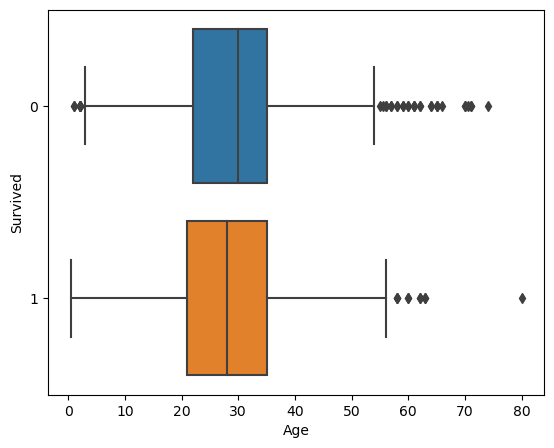

In [16]:
plt.figure().set_figheight(5)
ax = sns.boxplot(x=training_dataset.Age, y=training_dataset.Survived, orient='h')

plt.show()

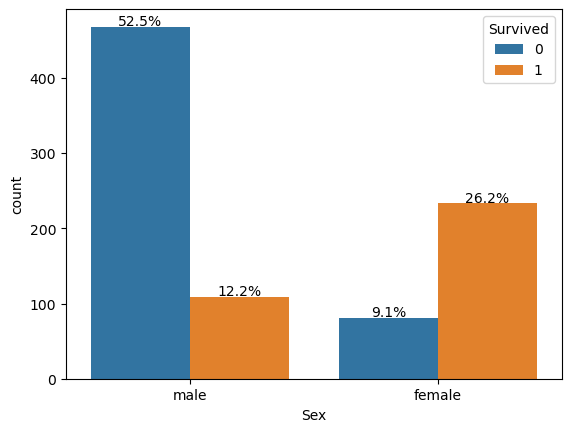

In [17]:
ax = sns.countplot(x=training_dataset.Sex, hue=training_dataset.Survived)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(training_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

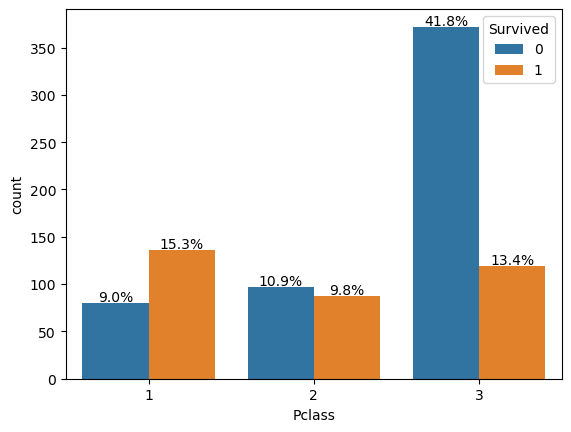

In [18]:
ax = sns.countplot(x=training_dataset.Pclass, hue=training_dataset.Survived)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(training_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

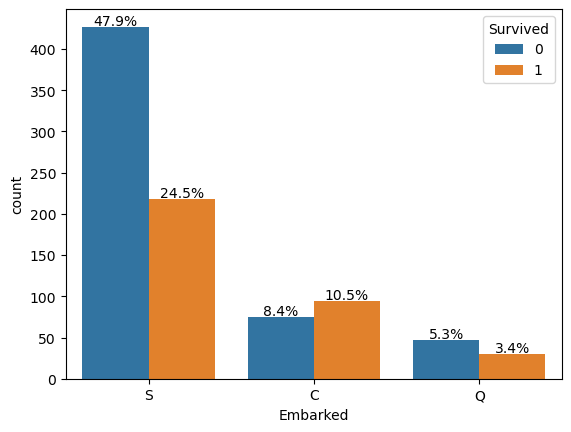

In [19]:
ax = sns.countplot(x=training_dataset.Embarked, hue=training_dataset.Survived)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(training_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Alternate Preprocessing step which is used for modeling </p>

In [20]:
# preprocessing
def data_prep_for_Modeling(training_dataset):
  if 'Sex' in training_dataset.columns:
    training_dataset.Sex = training_dataset.Sex.map({'male': 1, 'female': 0}).astype(int)
  if 'Embarked' in training_dataset.columns:
    training_dataset.Embarked = training_dataset.Embarked.map({'S': 0, 'C': 1, 'Q': 2}).astype(int)
  return training_dataset

In [21]:
training_dataset = data_prep_for_Modeling(training_dataset)

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Correlation map using training and testing dataset  </p>

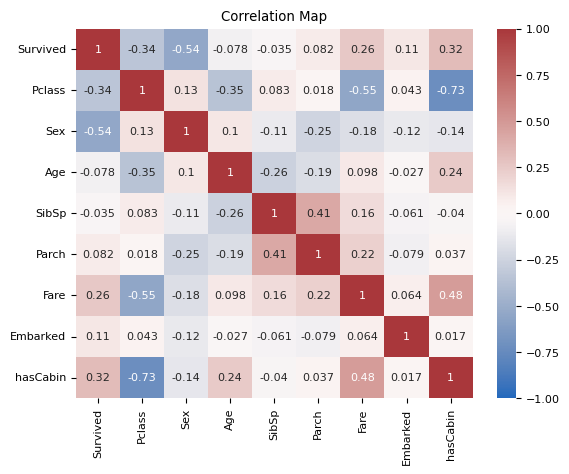

In [22]:
# correlation heat map
plt.rcParams['font.size'] =8
corr =training_dataset.corr()
sns.heatmap(corr, annot = True, cmap='vlag', vmax=1, vmin=-1).set_title("Correlation Map")
plt.show()

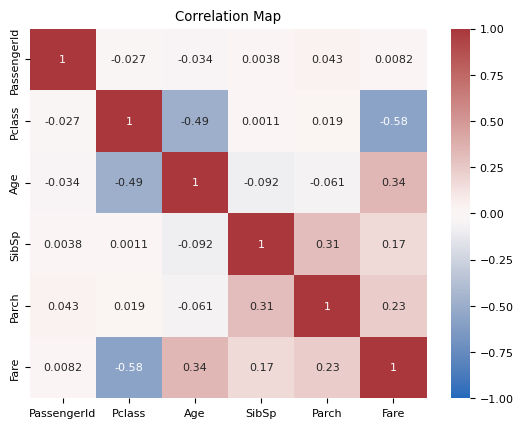

In [23]:
# correlation heat map
plt.rcParams['font.size'] =8
corr =testing_dataset.corr()
sns.heatmap(corr, annot = True, cmap='vlag', vmax=1, vmin=-1).set_title("Correlation Map")
plt.show()

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Now apply Feature selection approach which is feature variable and which is target variable</p>

In [24]:
# dividing data into 2 variables. 'Survived' as dependent variable and the rest are independent variable.
X=training_dataset.drop(['Survived'],axis=1)
y=training_dataset.Survived.values

In [25]:
# dividing data for training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y,train_size=0.8, test_size=0.2, random_state=42)

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Apply MUltilayerperceptronClassifier  </p>

In [26]:
# training the model
model = MLPClassifier(activation='logistic', max_iter=50000000, verbose=1, learning_rate='adaptive')
model.fit(X_train, y_train)

Iteration 1, loss = 0.66885843
Iteration 2, loss = 0.64852418
Iteration 3, loss = 0.63548934
Iteration 4, loss = 0.62378268
Iteration 5, loss = 0.61537411
Iteration 6, loss = 0.61081921
Iteration 7, loss = 0.60734386
Iteration 8, loss = 0.60484799
Iteration 9, loss = 0.60268652
Iteration 10, loss = 0.60158296
Iteration 11, loss = 0.60022151
Iteration 12, loss = 0.59916270
Iteration 13, loss = 0.59783348
Iteration 14, loss = 0.59652961
Iteration 15, loss = 0.59506059
Iteration 16, loss = 0.59355922
Iteration 17, loss = 0.59220195
Iteration 18, loss = 0.59075303
Iteration 19, loss = 0.58922778
Iteration 20, loss = 0.58780912
Iteration 21, loss = 0.58664416
Iteration 22, loss = 0.58457488
Iteration 23, loss = 0.58412000
Iteration 24, loss = 0.58251016
Iteration 25, loss = 0.58049031
Iteration 26, loss = 0.57853838
Iteration 27, loss = 0.57680862
Iteration 28, loss = 0.57532263
Iteration 29, loss = 0.57400840
Iteration 30, loss = 0.57182324
Iteration 31, loss = 0.57031738
Iteration 32, los

MLPClassifier(activation='logistic', learning_rate='adaptive',
              max_iter=50000000, verbose=1)

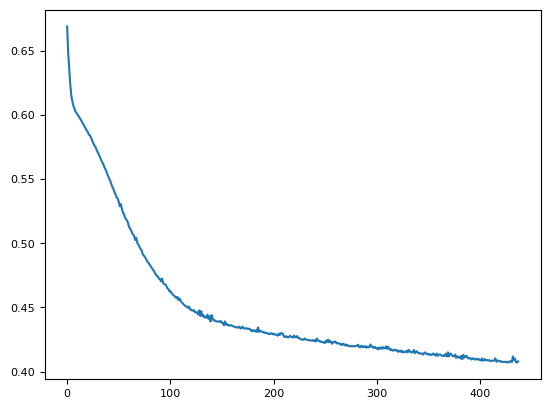

In [27]:
# plotting model loss curve
plt.plot(model.loss_curve_)
plt.show()

In [28]:
# getting the prediction with ML model
y_pred = model.predict(X_val)

In [29]:
# confusion matrix
pred_table = pd.DataFrame(confusion_matrix(y_true=y_val, y_pred=y_pred), columns=['Predicted 0','Predicted 1'], index=['Actual 0','Actual 1'])
pred_table

,Predicted 0,Predicted 1
Actual 0,90,15
Actual 1,18,56


In [30]:
# accuracy score
str(accuracy_score(y_val,y_pred) * 100 )+ ' %'

'81.56424581005587 %'

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px"> Apply  Multinomial naive bayes classifier</p>

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X, y,train_size=0.8, test_size=0.2, random_state=42)
from sklearn.naive_bayes import MultinomialNB
mln= MultinomialNB()
mln.fit(X_train,y_train)
print(mln.score(X_val,y_val))
pred=mln.predict(X_val)
print(pred)
print(accuracy_score(y_val,pred))
print(confusion_matrix(y_val,pred))
print(classification_report(y_val,pred))
print(mean_squared_error(y_val,pred))
print(mean_squared_log_error(y_val,pred))

0.7430167597765364
[1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 1
 0 0 0 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1]
0.7430167597765364
[[93 12]
 [34 40]]
              precision    recall  f1-score   support

           0       0.73      0.89      0.80       105
           1       0.77      0.54      0.63        74

    accuracy                           0.74       179
   macro avg       0.75      0.71      0.72       179
weighted avg       0.75      0.74      0.73       179

0.2569832402234637
0.12346837229182829


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">  # RandomForestClassifier</p>

In [32]:
from sklearn.ensemble import RandomForestClassifier
Rclf=RandomForestClassifier()
Rclf.fit(X_train,y_train)
print("Accuracy: {}".format(Rclf.score(X_val,y_val)))
pred1=Rclf.predict(X_val)
print(pred1)
print(accuracy_score(y_val,pred1))
print(confusion_matrix(y_val,pred1))
print(classification_report(y_val,pred1))
print(mean_squared_error(y_val,pred1))
print(mean_squared_log_error(y_val,pred1))

Accuracy: 0.8156424581005587
[1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1
 1 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 1
 0 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1]
0.8156424581005587
[[88 17]
 [16 58]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
           1       0.77      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

0.18435754189944134
0.08857513664413769


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px"># DecisionTreeClassifier</p>

In [33]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)
print("Accuracy: {}".format(dtc.score(X_val,y_val)))
pred2=dtc.predict(X_val)
print(pred2)
print(accuracy_score(y_val,pred2))
print(confusion_matrix(y_val,pred2))
print(classification_report(y_val,pred2))
print(mean_squared_error(y_val,pred2))
print(mean_squared_log_error(y_val,pred2))

Accuracy: 0.8156424581005587
[1 1 0 1 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 1
 0 1 1 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1
 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1]
0.8156424581005587
[[87 18]
 [15 59]]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       105
           1       0.77      0.80      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

0.18435754189944134
0.08857513664413769


# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px"># EDA using testing data  </p>

In [34]:
testing_dataset = data_prep_for_EDA(testing_dataset)
testing_dataset = data_prep_for_Modeling(testing_dataset)
testing_dataset.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,hasCabin
0,3,1,34.5,0,0,7.8292,2,0
1,3,0,47.0,1,0,7.0000,0,0
2,2,1,62.0,0,0,9.6875,2,0
3,3,1,27.0,0,0,8.6625,0,0
4,3,0,22.0,1,1,12.2875,0,0


In [35]:
testing_dataset.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
hasCabin    0
dtype: int64

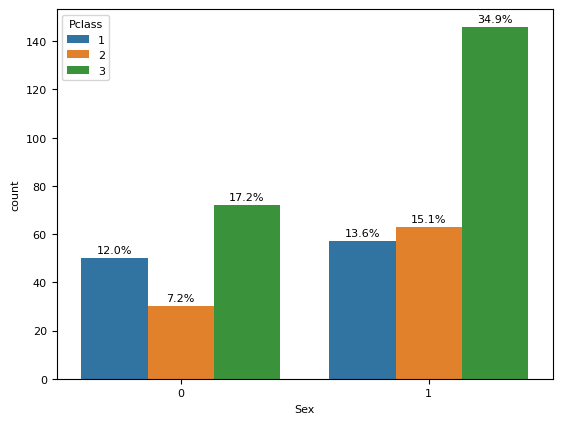

In [36]:
ax = sns.countplot(x=testing_dataset.Sex, hue=testing_dataset.Pclass)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(testing_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

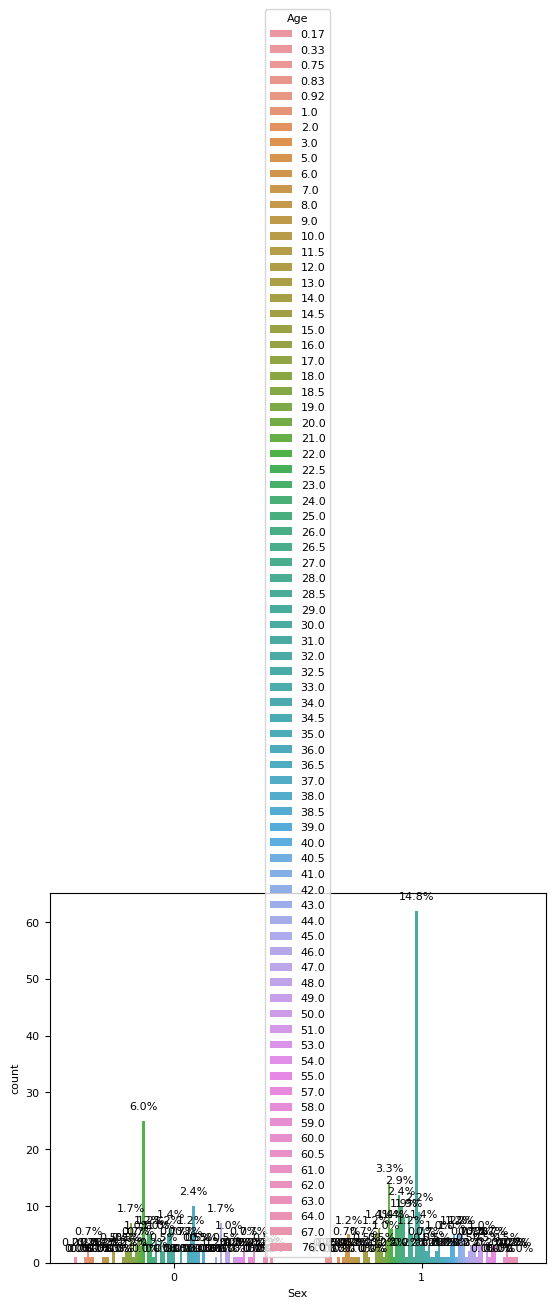

In [37]:
ax = sns.countplot(x=testing_dataset.Sex, hue=testing_dataset.Age)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(testing_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

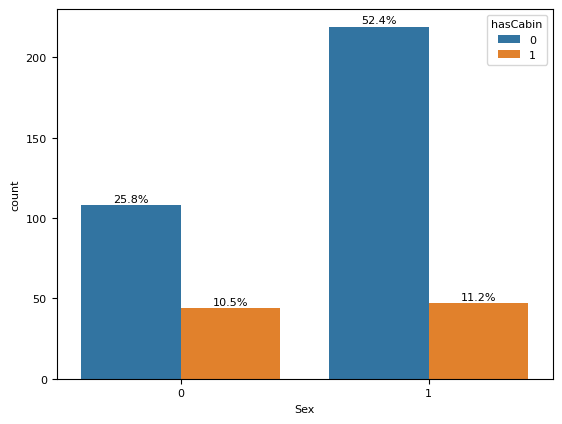

In [38]:
ax = sns.countplot(x=testing_dataset.Sex, hue=testing_dataset.hasCabin)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(testing_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

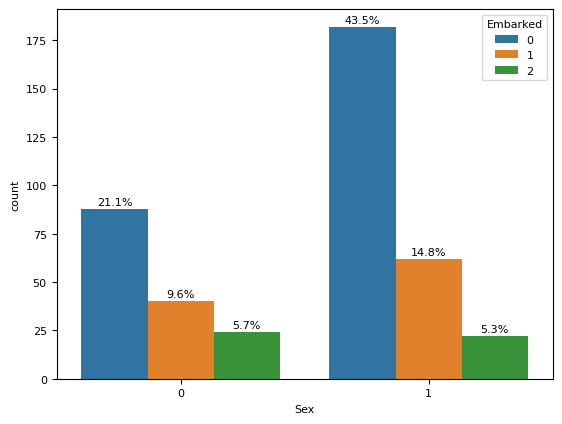

In [39]:
ax = sns.countplot(x=testing_dataset.Sex, hue=testing_dataset.Embarked)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(testing_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

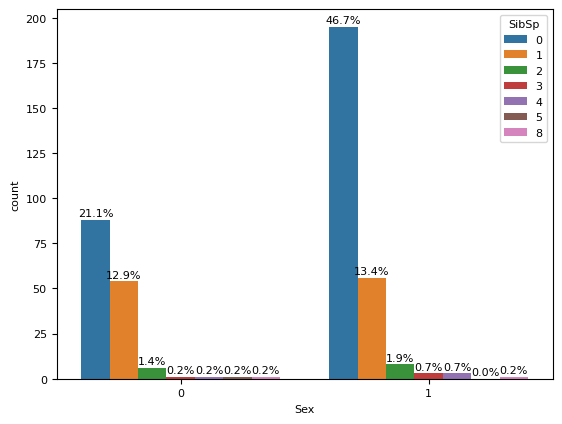

In [40]:
ax = sns.countplot(x=testing_dataset.Sex, hue=testing_dataset.SibSp)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(testing_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

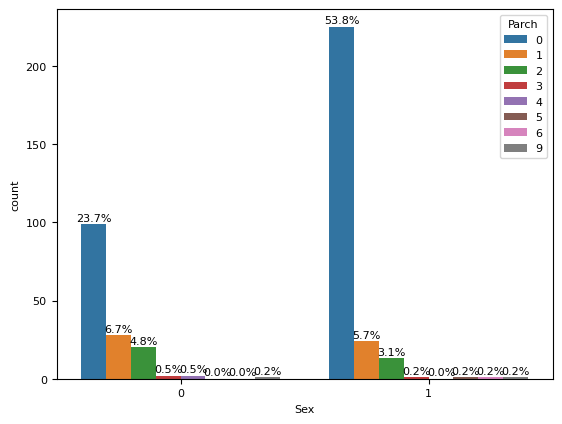

In [41]:
ax = sns.countplot(x=testing_dataset.Sex, hue=testing_dataset.Parch)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/float(len(testing_dataset.Sex)))
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y),ha='center')
plt.show()

# <p style="background-color:darkgreen ;font-size:120%;text-align:center;color:white;letter-spacing:1px;font-family:bold;border-radius:50px;padding:20px">Submission process has done </p>

In [42]:
from sklearn.ensemble import RandomForestClassifier

y = training_dataset["Survived"]

features = ["Pclass", "Sex", "SibSp", "Parch"]
X = pd.get_dummies(training_dataset[features])
X_test = pd.get_dummies(testing_dataset[features])

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X, y)
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId':pd.read_csv("/kaggle/input/titanic/test.csv").PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("MY submission was successfully saved!")

MY submission was successfully saved!
